## Chapter 11 of *R for Data Science* (2e, 2023)

In [1]:
from hea import data
from hea.ggplot import plot_annotation, plot_layout, guide_area, theme

mpg = data("mpg", package="ggplot2")

### 11.2

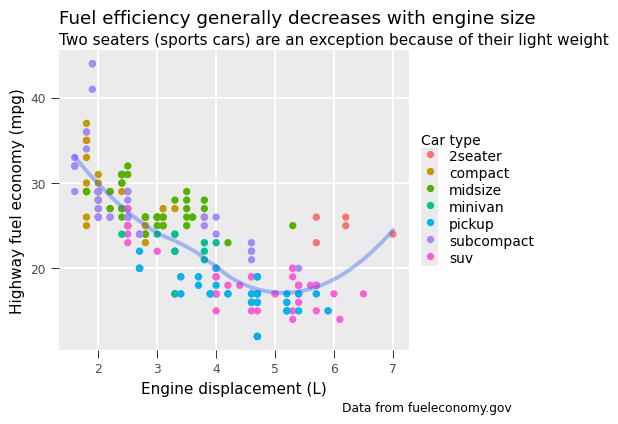

In [2]:
(
    mpg.ggplot(x = "displ", y = "hwy")
        .geom_point(color = "class")
        .geom_smooth(se = False)
        .labs(
            x = "Engine displacement (L)",
            y = "Highway fuel economy (mpg)",
            color = "Car type",
            title = "Fuel efficiency generally decreases with engine size",
            subtitle = "Two seaters (sports cars) are an exception because of their light weight",
            caption = "Data from fueleconomy.gov"
        )
)

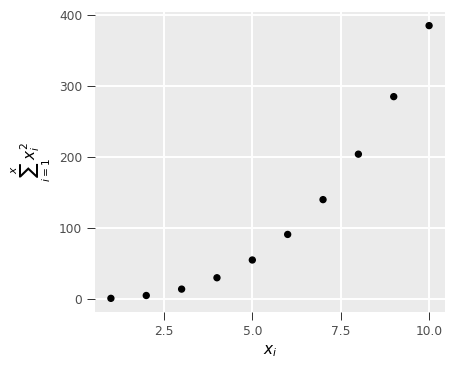

In [3]:
import hea

x = hea.R.seq(1, 10)
y = hea.R.cumsum(x ** 2)
df = hea.from_dict({
        "x": x,
        "y": y,
    })

(
    df
        .ggplot(x="x", y="y")
        .geom_point()
        .labs(
            x = r"$x_i$",
            y = r"$\sum^{x}_{i=1}x^2_i$"
        )
)

### 11.3

In [4]:
from hea import desc, case_when, col

label_info = (
    mpg.arrange(desc("displ"))
       .group_by("drv")
       .slice_head(n=1)
       .mutate(
           drive_type=case_when(
               (col("drv") == "f", "front-wheel drive"),
               (col("drv") == "r", "rear-wheel drive"),
               (col("drv") == "4", "4-wheel drive"),
           )
       )
       .select("displ", "hwy", "drv", "drive_type")
)

# from hea import desc, col, lit, when
# label_info = (
#     mpg.group_by("drv")
#        .slice_max("displ", n=1, with_ties=False)
#        .mutate(
#            drive_type=(
#                when(col("drv") == "f").then(lit("front-wheel drive"))
#                .when(col("drv") == "r").then(lit("rear-wheel drive"))
#                .when(col("drv") == "4").then(lit("4-wheel drive"))
#            ),
#        )
#        .select("displ", "hwy", "drv", "drive_type")
# )


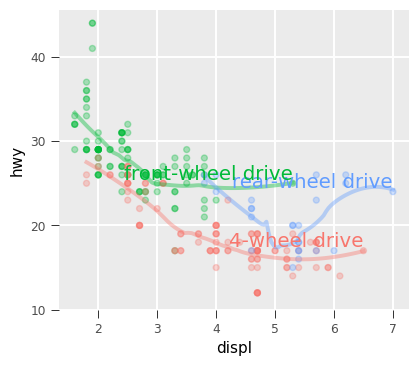

In [5]:
from hea.ggplot import theme

(
    mpg
        .ggplot(x = "displ", y = "hwy", color = "drv")
        .geom_point(alpha = 0.3)
        .geom_smooth(se = False)
        .geom_text(
            data = label_info, 
            x = "displ", y = "hwy", label = "drive_type",
            fontface = "bold", size = 5, hjust = "right", vjust = "bottom"
        ) + theme(legend_position = "none")
)

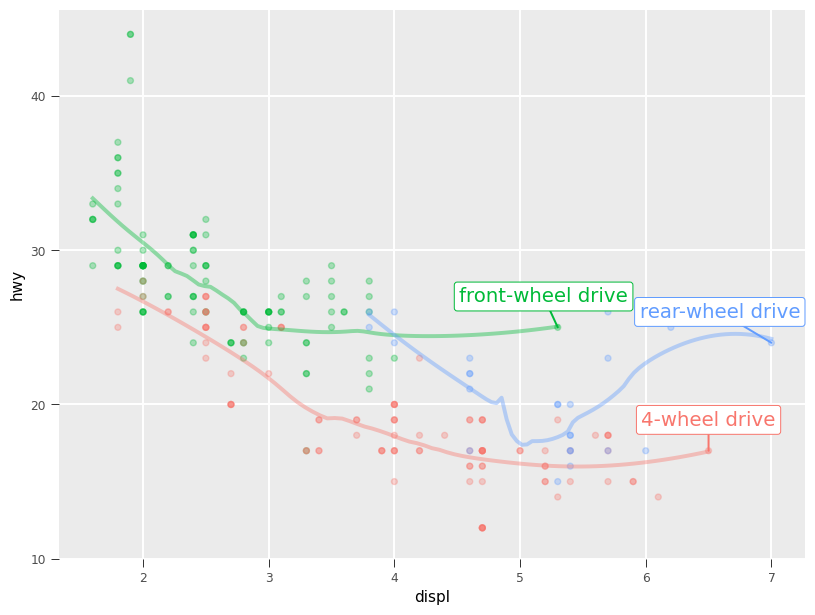

In [6]:
(
    mpg
        .ggplot(x = "displ", y = "hwy", color = "drv")
        .geom_point(alpha = 0.3)
        .geom_smooth(se = False)
        .geom_label_repel(
            data = label_info, 
            x = "displ", y = "hwy", label = "drive_type",
            fontface = "bold", size = 5, nudge_y = 2
        ) + theme(legend_position = "none")
).show(figsize=(8,6))

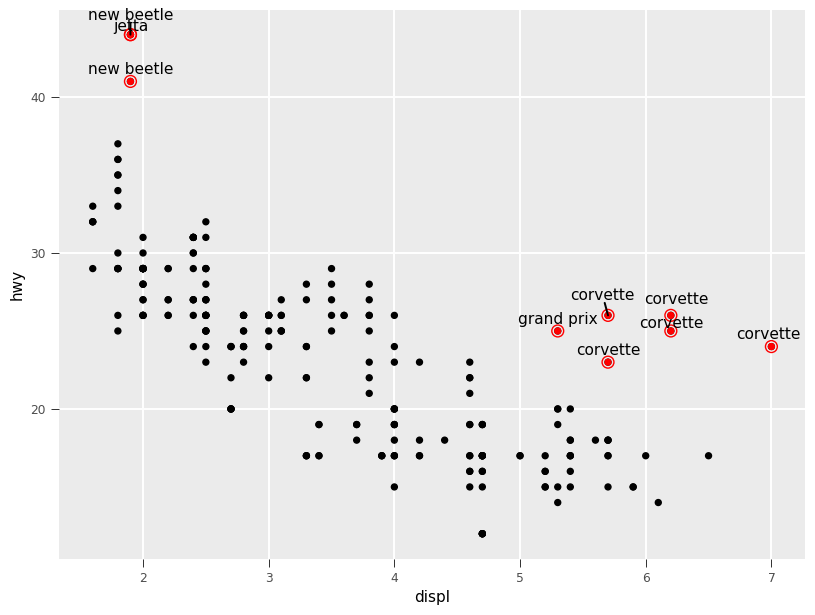

In [7]:
from hea import col
potential_outliers = mpg.filter((col("hwy") > 40) | ((col("hwy") > 20) & (col("displ") > 5)))

(
    mpg
        .ggplot(x = "displ", y = "hwy")
        .geom_point()
        .geom_text_repel(data = potential_outliers, label = "model")
        .geom_point(data = potential_outliers, color = "red")
        .geom_point(
            data = potential_outliers,
            color = "red", size = 3, shape = "circle open"
        )
).show(figsize=(8,6))


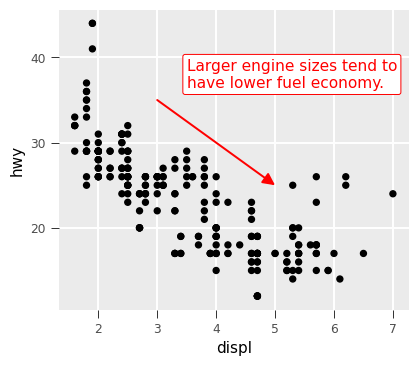

In [10]:
from hea.R import str_wrap
from hea.ggplot import arrow

trend_text = str_wrap(
    "Larger engine sizes tend\nto have lower fuel economy.", 
    width = 30)

(
    mpg.ggplot(x = "displ", y = "hwy")
        .geom_point()
        .annotate(
            geom = "label", x = 3.5, y = 38,
            label = trend_text,
            hjust = "left", color = "red"
        ).annotate(
            geom = "segment",
            x = 3, y = 35, xend = 5, yend = 25, color = "red",
            arrow = arrow(type = "closed") 
        )
)

### 11.6

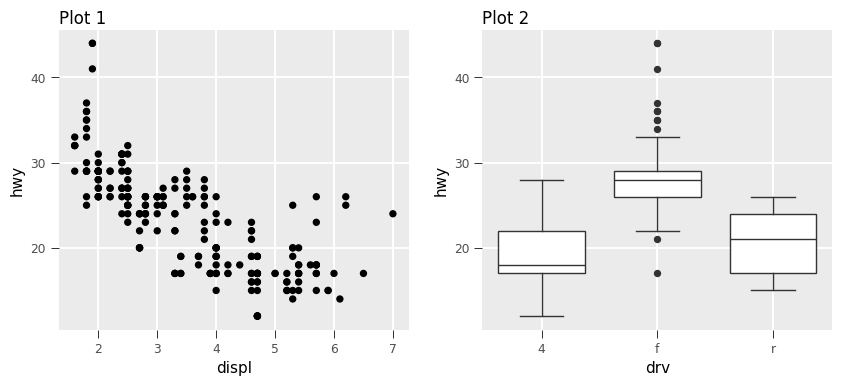

<Figure size 827x373 with 0 Axes>

In [ ]:
p1 = mpg.ggplot(x = "displ", y = "hwy").geom_point().labs(title = "Plot 1")
p2 = mpg.ggplot(x = "drv", y = "hwy").geom_boxplot().labs(title = "Plot 2")
p3 = mpg.ggplot(x = "cty", y = "hwy").geom_point().labs(title = "Plot 3")

p1 + p2

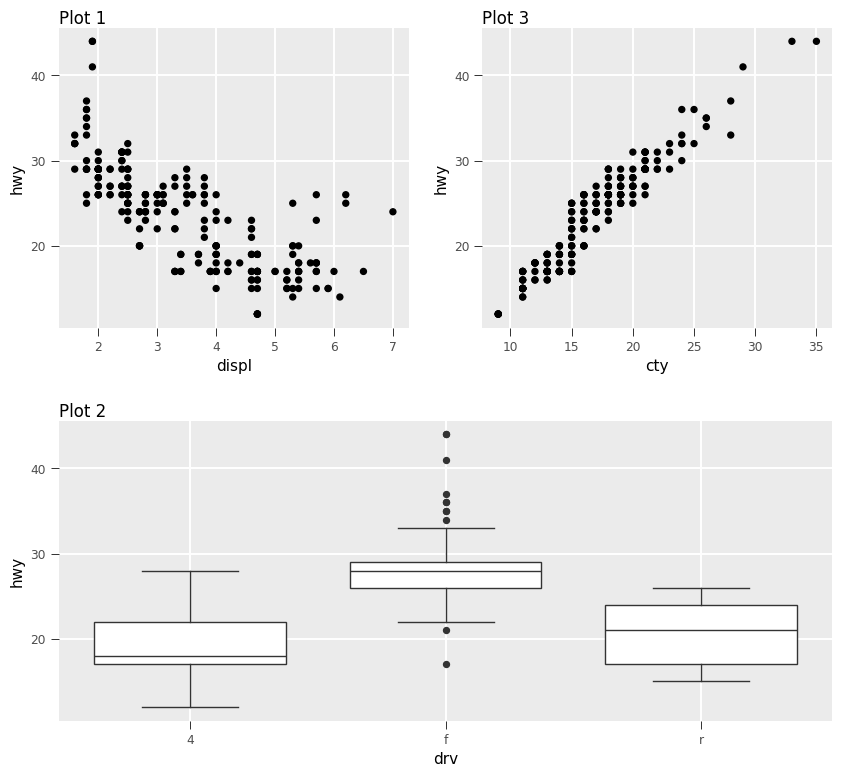

<Figure size 827x766 with 0 Axes>

In [ ]:
(p1 + p3) / p2

<Figure size 800x800 with 0 Axes>

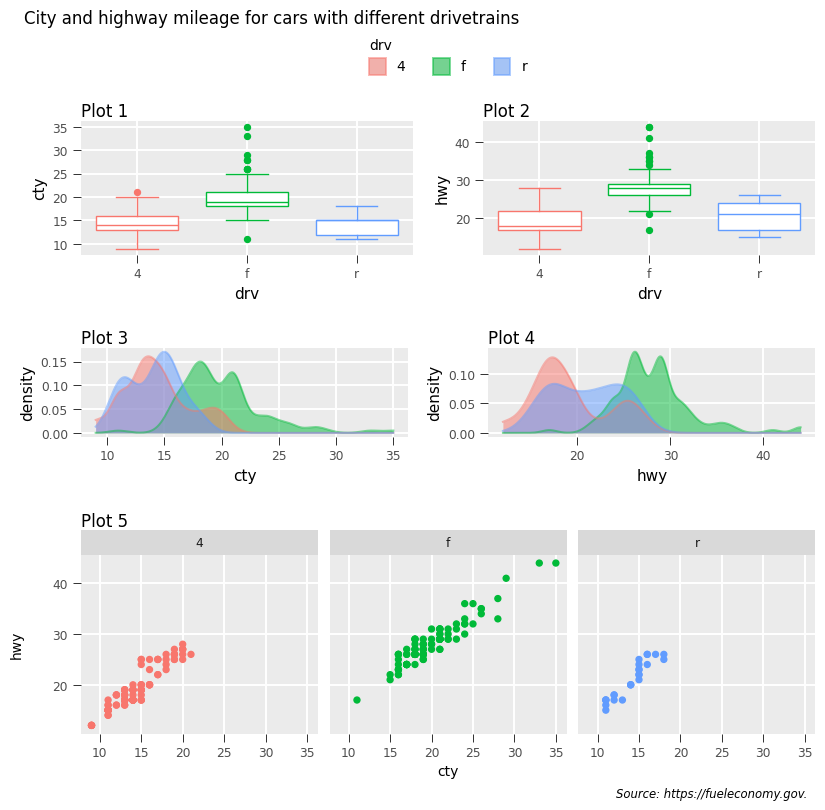

In [ ]:

p1 = mpg.ggplot(x = "drv", y = "cty", color = "drv").geom_boxplot(show_legend = False).labs(title = "Plot 1")
p2 = mpg.ggplot(x = "drv", y = "hwy", color = "drv").geom_boxplot(show_legend = False).labs(title = "Plot 2")
p3 = mpg.ggplot(x = "cty", color = "drv", fill = "drv").geom_density(alpha = 0.5).labs(title = "Plot 3")
p4 = mpg.ggplot(x = "hwy", color = "drv", fill = "drv").geom_density(alpha = 0.5).labs(title = "Plot 4")
p5 = mpg.ggplot(x = "cty", y = "hwy", color = "drv").geom_point(show_legend = False).facet_wrap("~drv").labs(title = "Plot 5")

p = (guide_area() / (p1 +p2) / (p3 + p4) / p5) + plot_annotation(
    title = "City and highway mileage for cars with different drivetrains",
    caption = "Source: https://fueleconomy.gov."
) + plot_layout(
    guides = "collect",
    heights = [1, 3, 2, 4],
) & theme(legend_position = "top")
p.show(figsize=(8, 8))